In [ ]:
from pathlib import Path

DATA_DIR  = Path('path_to_processed_data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'

In [ ]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed
from plots import plot_f1_training_curves, build_summary_df, plot_summary_table, plot_metrics_comparison, plot_confusion_matrix, plot_loss_and_f1_curves
EXPERIMENT_PATH = os.path.join(REPO_PATH, 'experiments/transformer_architecture')
sys.path.insert(0, EXPERIMENT_PATH)
from embeddings_plots import extract_embeddings, get_best_model, plot_tsne_comparison
from pooling_plots import extract_attention_weights, plot_attention_heatmap_comparison, plot_attention_profiles

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cuda


In [10]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
LR = 3e-4
REPR = "mfcc"
D_MODEL = [64, 128, 256, 512]
NHEAD = 4
CLASS_NAMES = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "unknown", "silence"]

In [4]:
train_ds, valid_ds, test_ds = get_datasets(data_format=REPR, train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
precompute_features(train_ds, Path('/kaggle/working/cache/train_mfcc'))
precompute_features(valid_ds, Path('/kaggle/working/cache/valid_mfcc'))
precompute_features(test_ds,  Path('/kaggle/working/cache/test_mfcc'))

train_cached = CachedDataset('/kaggle/working/cache/train_mfcc')
valid_cached = CachedDataset('/kaggle/working/cache/valid_mfcc')
test_cached  = CachedDataset('/kaggle/working/cache/test_mfcc')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train_mfcc


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid_mfcc


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test_mfcc


In [11]:
def run_dmodel_experiment(model_factory, D_MODEL, seeds, nhead=NHEAD, epochs=EPOCHS,
    batch_size=BATCH_SIZE, lr=LR, device=device, model_name='Model'):
    """
    Trains and evaluates model_factory(d_model) for each d_model x seed combination.

    Args:
        model_factory: callable(d_model: int) -> nn.Module
        d_models: list of int — embedding dimensions to sweep
        seeds: list of int — random seeds for reproducibility
        nhead: int — must divide every d_model in d_models
        model_name: str — used in log output
        epochs, batch_size, lr, device: standard training hyperparameters

    Returns:
        results[d_model][seed] = {
            'history', 'valid_acc', 'valid_loss', 'valid_f1',
            'test_acc', 'test_macro_f1', 'test_weighted_f1',
            'test_cm', 'model'
        }
    """
    results = {}

    for d_model in D_MODEL:
        results[d_model] = {}

        for seed in seeds:
            print(f'\n[{model_name}] d_model={d_model} | seed={seed}')
            print('-' * 50)

            set_seed(seed)
            model = model_factory(d_model).to(device)

            model, history = train(model, train_cached, valid_cached, epochs=epochs,
                batch_size=batch_size, lr=lr, device=str(device), verbose=True,
                verbose_interval=5)

            preds, labels = predict(model, test_cached, device=str(device), batch_size=batch_size)
            test_results = evaluate(preds, labels, print_report=False)

            results[d_model][seed] = {
                'history': history,
                'valid_acc': history['valid_acc'][-1],
                'valid_loss': history['valid_loss'][-1],
                'valid_f1': history['valid_f1'][-1],
                'test_acc': test_results['acc'],
                'test_macro_f1': test_results['macro_f1'],
                'test_weighted_f1': test_results['weighted_f1'],
                'test_cm': test_results['cm'],
                'model': model,
            }

    return results

In [6]:
def transformer_dmodel_factory(d_model):
    return Transformer(n_features=40, n_timesteps=101, num_classes=12, d_model=d_model,
        nhead=NHEAD, num_layers=4, dropout=0.1, pooling='mean')

def cnn_transformer_dmodel_factory(d_model):
    return CNNTransformer(n_features=40, n_timesteps=101, num_classes=12, base_channels=32,
        d_model=d_model, nhead=NHEAD, num_layers=4, dropout=0.1, pooling='mean')

In [26]:
transformer_dmodel_results = run_dmodel_experiment(model_factory=transformer_dmodel_factory,
    D_MODEL=D_MODEL, seeds=SEEDS, model_name='CNNTransformer')


[CNNTransformer] d_model=64 | seed=0
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.2093 | Valid Loss: 0.2406 | Valid Acc: 0.9243 | Valid Macro F1: 0.8800
Epoch 10/30 | Train Loss: 0.1114 | Valid Loss: 0.1910 | Valid Acc: 0.9454 | Valid Macro F1: 0.9133
Epoch 15/30 | Train Loss: 0.0666 | Valid Loss: 0.1920 | Valid Acc: 0.9495 | Valid Macro F1: 0.9187
Epoch 20/30 | Train Loss: 0.0429 | Valid Loss: 0.1957 | Valid Acc: 0.9527 | Valid Macro F1: 0.9281
Epoch 25/30 | Train Loss: 0.0320 | Valid Loss: 0.2120 | Valid Acc: 0.9530 | Valid Macro F1: 0.9296
Epoch 30/30 | Train Loss: 0.0279 | Valid Loss: 0.2119 | Valid Acc: 0.9528 | Valid Macro F1: 0.9284
Best validation accuracy: 0.9530

[CNNTransformer] d_model=64 | seed=1
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1987 | Valid Loss: 0.2310 | Valid Acc: 0.9288 | Valid Macro F1: 0.8944
Epoch 10/30 | Train Loss: 0.1038 | Valid Loss: 0.1890 | Valid Acc: 0.9463 | Valid Macro F1: 0.9172

### Transformer results

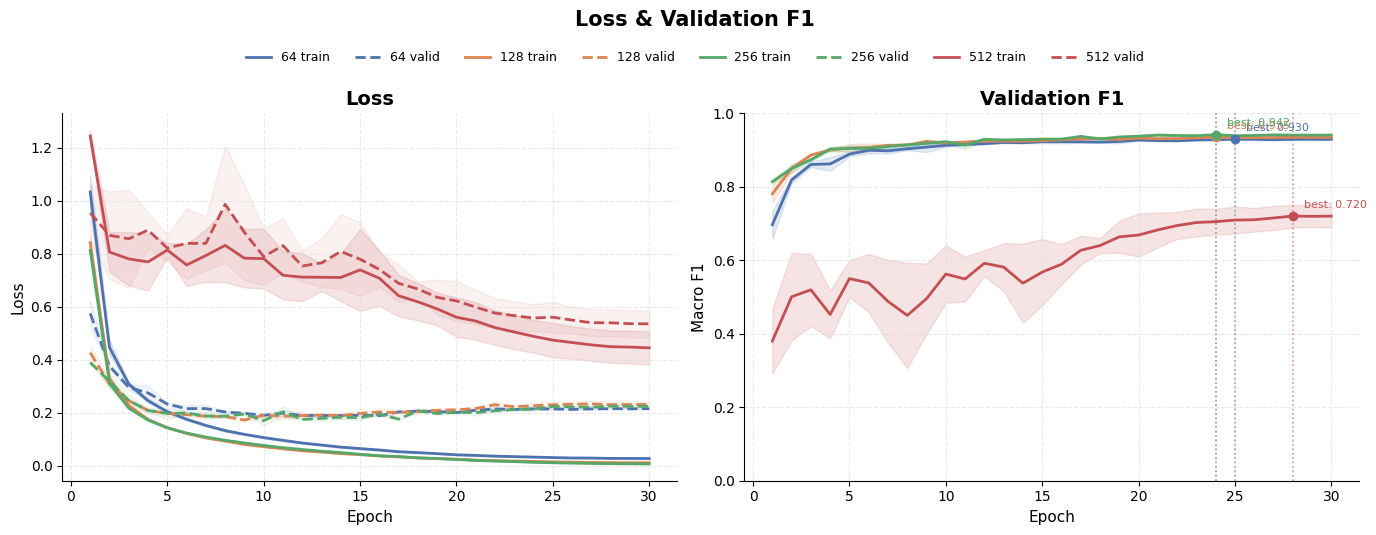

In [30]:
plot_loss_and_f1_curves(transformer_dmodel_results, group_name='')

In [31]:
summary_df = build_summary_df({
    f'dmodel={p}': {'mfcc': v}
    for p, v in transformer_dmodel_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,dmodel=64,mfcc,0.9550 ± 0.0008,0.001,0.9051 ± 0.0054,0.006,0.9561 ± 0.0005,0.001
1,dmodel=128,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
2,dmodel=256,mfcc,0.9627 ± 0.0020,0.002,0.9161 ± 0.0033,0.004,0.9636 ± 0.0019,0.002
3,dmodel=512,mfcc,0.8287 ± 0.0128,0.015,0.7090 ± 0.0173,0.024,0.8247 ± 0.0142,0.017


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,dmodel=64,mfcc,0.9550 ± 0.0008,0.001,0.9051 ± 0.0054,0.006,0.9561 ± 0.0005,0.001
1,dmodel=128,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
2,dmodel=256,mfcc,0.9627 ± 0.0020,0.002,0.9161 ± 0.0033,0.004,0.9636 ± 0.0019,0.002
3,dmodel=512,mfcc,0.8287 ± 0.0128,0.015,0.7090 ± 0.0173,0.024,0.8247 ± 0.0142,0.017


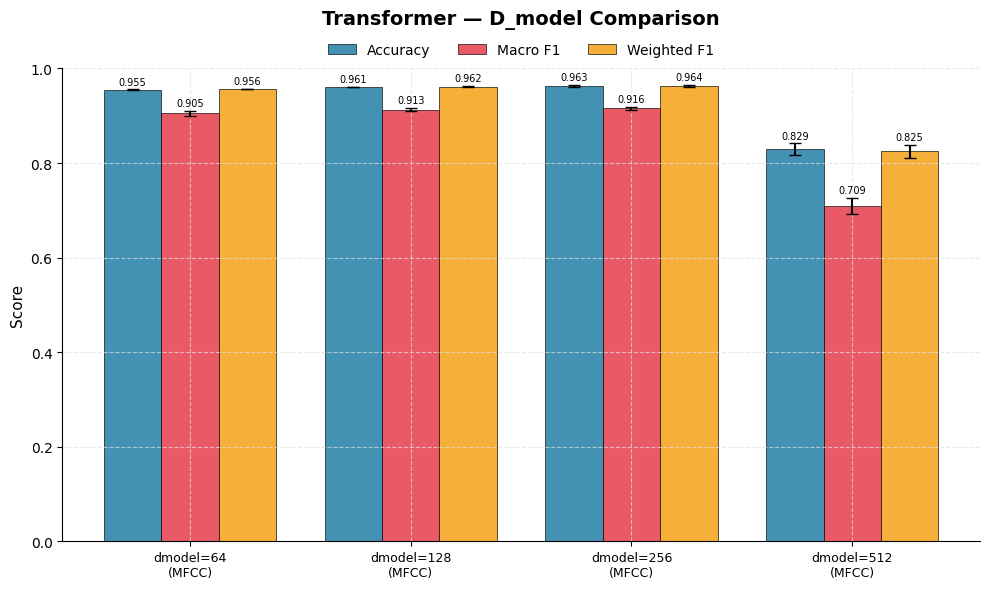

In [32]:
plot_metrics_comparison(summary_df, title='Transformer — D_model Comparison')

In [34]:
embeddings_per_dmodel = {}
for dmodel in D_MODEL:
    print(f'Extracting embeddings for dmodel={dmodel}...')
    model = get_best_model(transformer_dmodel_results, dmodel)
    embeddings, labels = extract_embeddings(model, test_cached, device)
    embeddings_per_dmodel[dmodel] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for dmodel=64...
  -> shape: (6865, 64)
Extracting embeddings for dmodel=128...
  -> shape: (6865, 128)
Extracting embeddings for dmodel=256...
  -> shape: (6865, 256)
Extracting embeddings for dmodel=512...
  -> shape: (6865, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


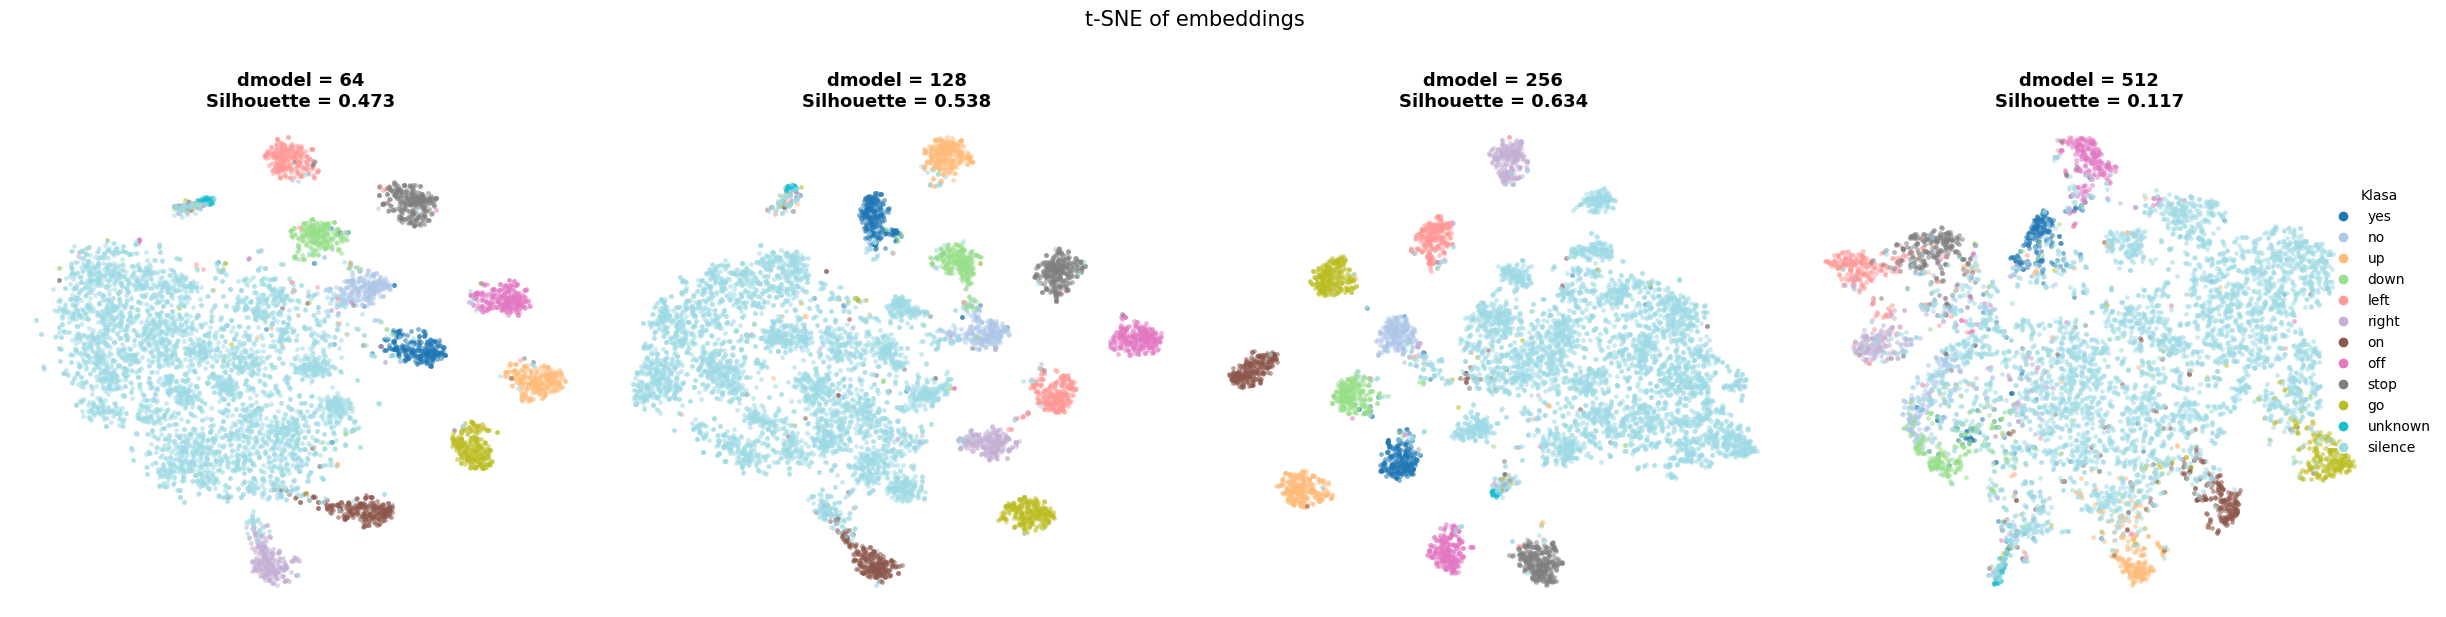

In [35]:
plot_tsne_comparison(embeddings_per_dmodel, CLASS_NAMES, key_label='dmodel')


 dmodel=64, seed=1, F1=0.9127


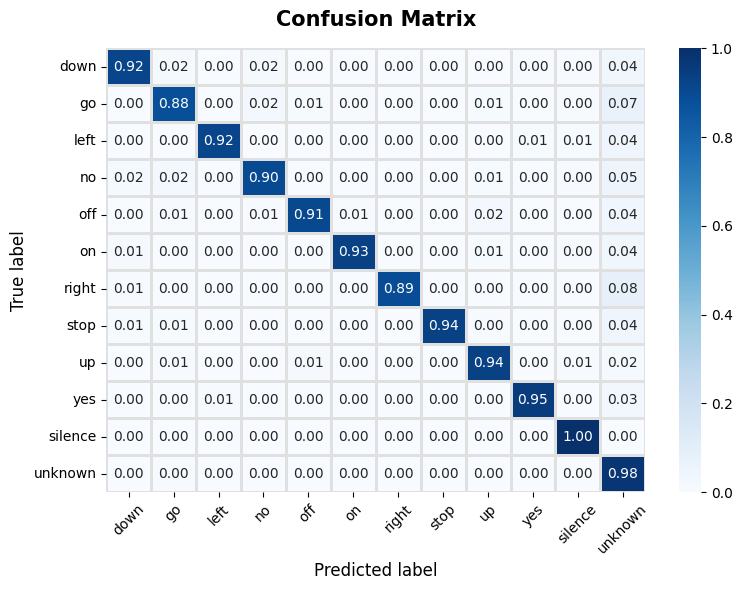


 dmodel=128, seed=1, F1=0.9152


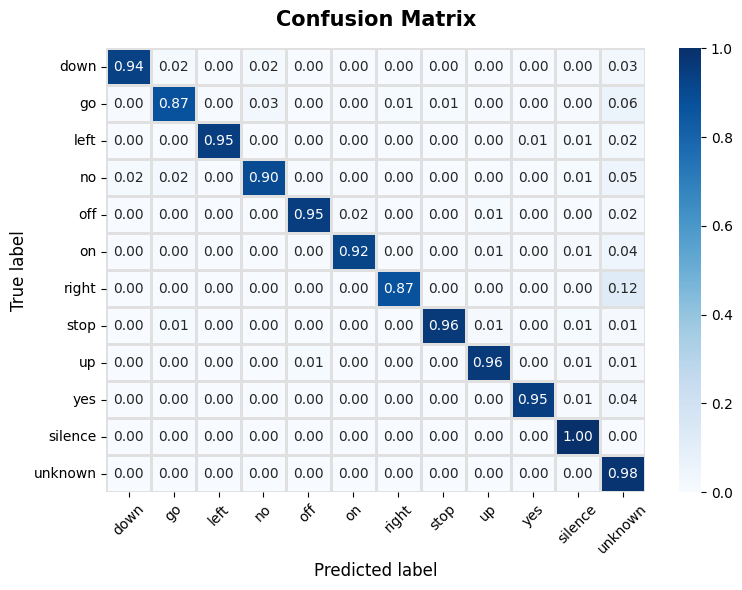


 dmodel=256, seed=2, F1=0.9197


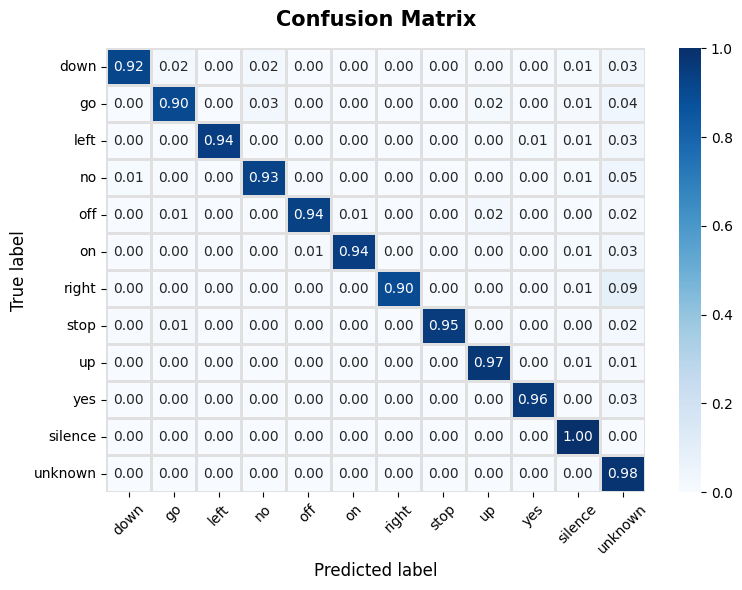


 dmodel=512, seed=1, F1=0.7335


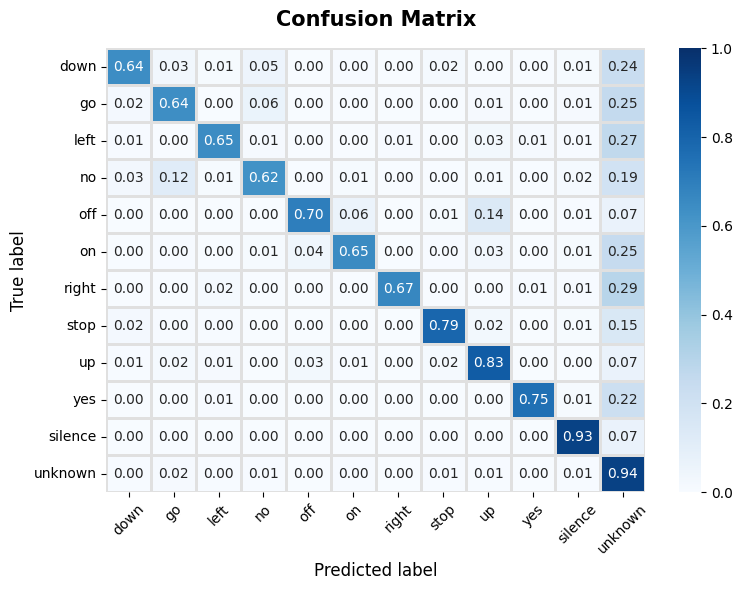

In [36]:
for dmodel in D_MODEL:
    best_seed = max(transformer_dmodel_results[dmodel], key=lambda s: transformer_dmodel_results[dmodel][s]['test_macro_f1'])
    best_result = transformer_dmodel_results[dmodel][best_seed]
    print(f'\n dmodel={dmodel}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])

### CNN Transformer

In [13]:
cnn_transformer_dmodel_results = run_dmodel_experiment(model_factory=cnn_transformer_dmodel_factory,
    D_MODEL=D_MODEL, seeds=SEEDS, model_name='CNNTransformer')


[CNNTransformer] d_model=64 | seed=0
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1142 | Valid Loss: 0.1893 | Valid Acc: 0.9429 | Valid Macro F1: 0.9102
Epoch 10/30 | Train Loss: 0.0597 | Valid Loss: 0.1854 | Valid Acc: 0.9486 | Valid Macro F1: 0.9220
Epoch 15/30 | Train Loss: 0.0360 | Valid Loss: 0.1856 | Valid Acc: 0.9534 | Valid Macro F1: 0.9307
Epoch 20/30 | Train Loss: 0.0190 | Valid Loss: 0.1919 | Valid Acc: 0.9606 | Valid Macro F1: 0.9411
Epoch 25/30 | Train Loss: 0.0067 | Valid Loss: 0.2181 | Valid Acc: 0.9587 | Valid Macro F1: 0.9402
Epoch 30/30 | Train Loss: 0.0032 | Valid Loss: 0.2318 | Valid Acc: 0.9577 | Valid Macro F1: 0.9391
Best validation accuracy: 0.9610

[CNNTransformer] d_model=64 | seed=1
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1113 | Valid Loss: 0.1771 | Valid Acc: 0.9495 | Valid Macro F1: 0.9215
Epoch 10/30 | Train Loss: 0.0554 | Valid Loss: 0.1561 | Valid Acc: 0.9593 | Valid Macro F1: 0.9401

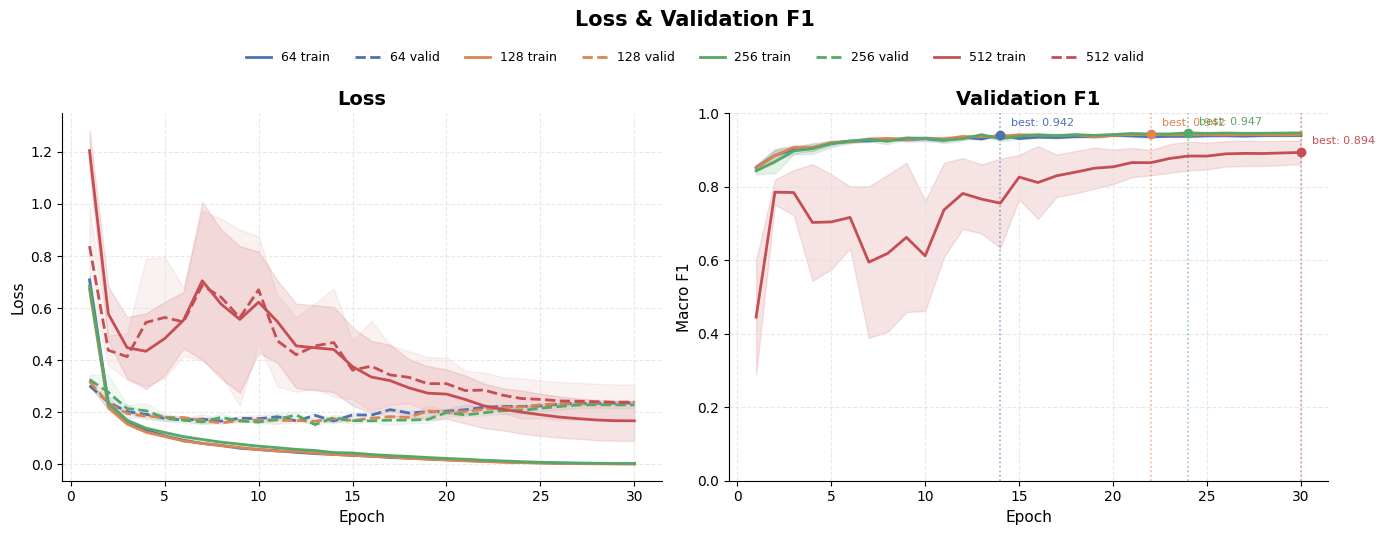

In [37]:
plot_loss_and_f1_curves(cnn_transformer_dmodel_results, group_name='')

In [38]:
summary_df = build_summary_df({
    f'dmodel={p}': {'mfcc': v}
    for p, v in cnn_transformer_dmodel_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,dmodel=64,mfcc,0.9678 ± 0.0017,0.002,0.9520 ± 0.0047,0.005,0.9676 ± 0.0017,0.002
1,dmodel=128,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
2,dmodel=256,mfcc,0.9699 ± 0.0015,0.001,0.9547 ± 0.0019,0.002,0.9698 ± 0.0015,0.002
3,dmodel=512,mfcc,0.9330 ± 0.0253,0.027,0.9016 ± 0.0382,0.042,0.9322 ± 0.0258,0.028


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,dmodel=64,mfcc,0.9678 ± 0.0017,0.002,0.9520 ± 0.0047,0.005,0.9676 ± 0.0017,0.002
1,dmodel=128,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
2,dmodel=256,mfcc,0.9699 ± 0.0015,0.001,0.9547 ± 0.0019,0.002,0.9698 ± 0.0015,0.002
3,dmodel=512,mfcc,0.9330 ± 0.0253,0.027,0.9016 ± 0.0382,0.042,0.9322 ± 0.0258,0.028


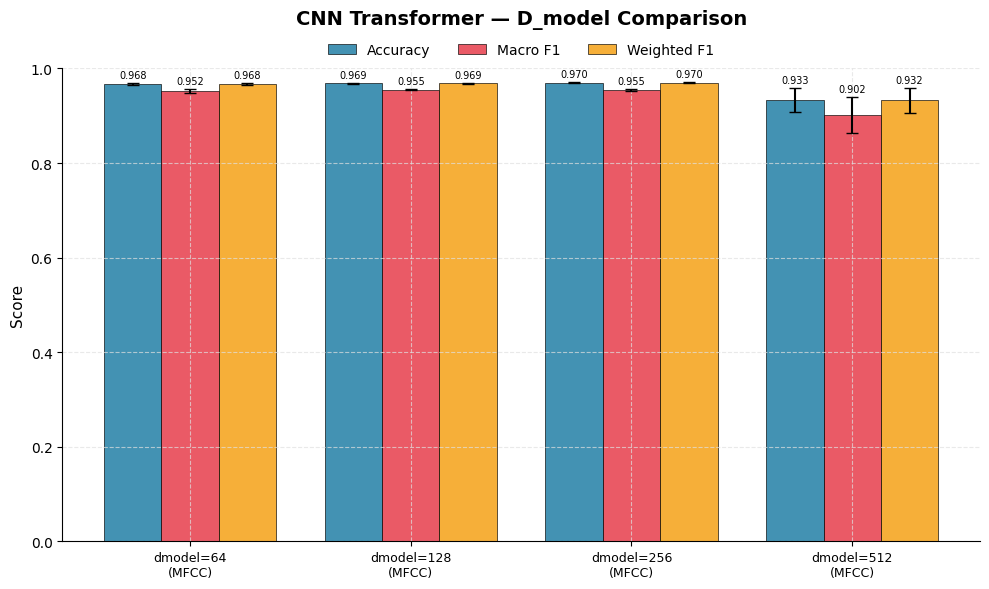

In [39]:
plot_metrics_comparison(summary_df, title='CNN Transformer — D_model Comparison')

In [20]:
embeddings_per_dmodel = {}
for dmodel in D_MODEL:
    print(f'Extracting embeddings for dmodel={dmodel}...')
    model = get_best_model(cnn_transformer_dmodel_results, dmodel)
    embeddings, labels = extract_embeddings_cnn_transformer(model, test_cached, device)
    embeddings_per_dmodel[dmodel] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for dmodel=64...
  -> shape: (6865, 64)
Extracting embeddings for dmodel=128...
  -> shape: (6865, 128)
Extracting embeddings for dmodel=256...
  -> shape: (6865, 256)
Extracting embeddings for dmodel=512...
  -> shape: (6865, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


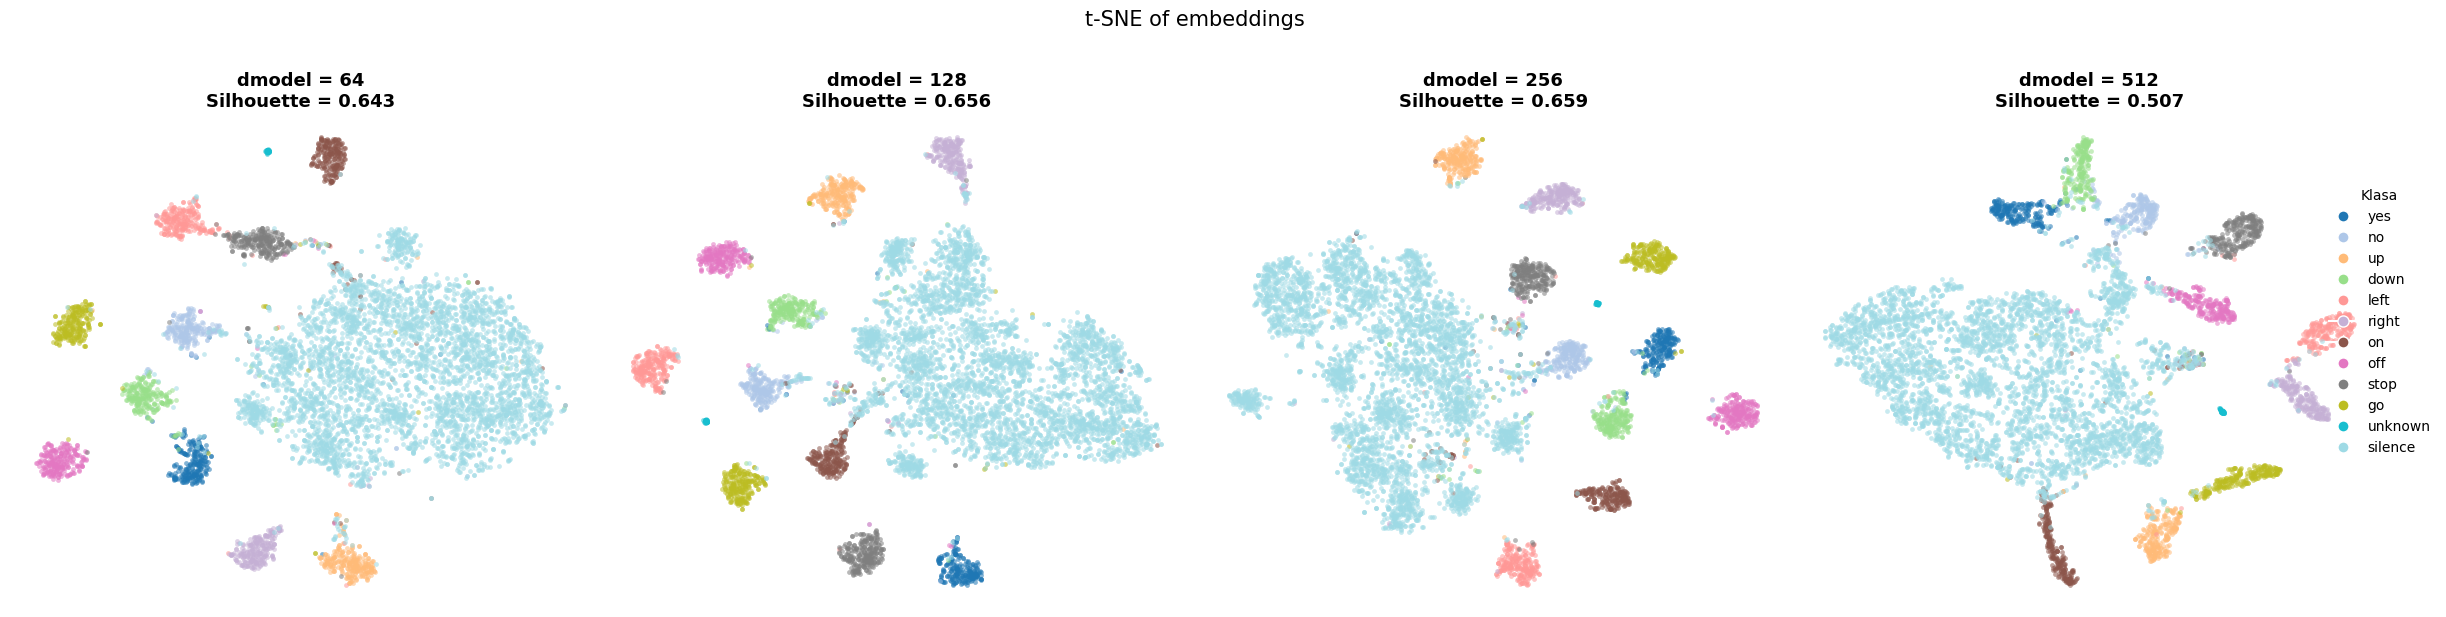

In [21]:
plot_tsne_comparison(embeddings_per_dmodel, CLASS_NAMES, key_label='dmodel')


 dmodel=64, seed=2, F1=0.9554


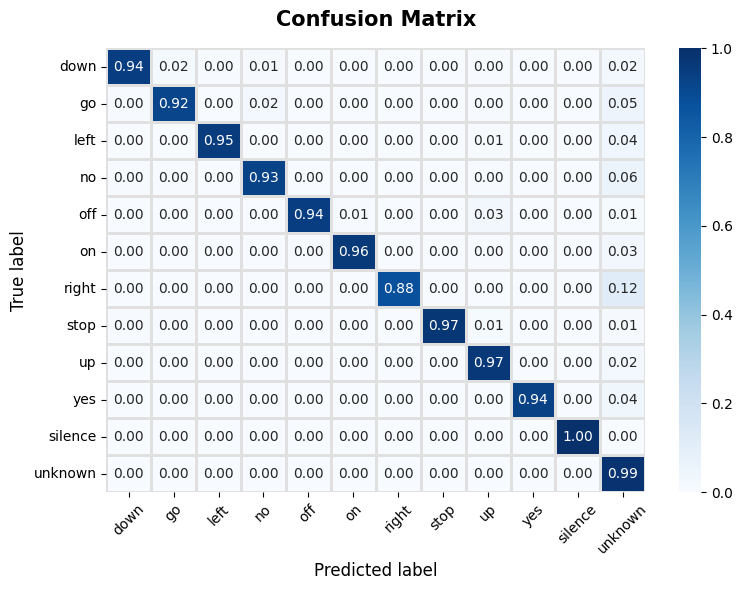


 dmodel=128, seed=2, F1=0.9566


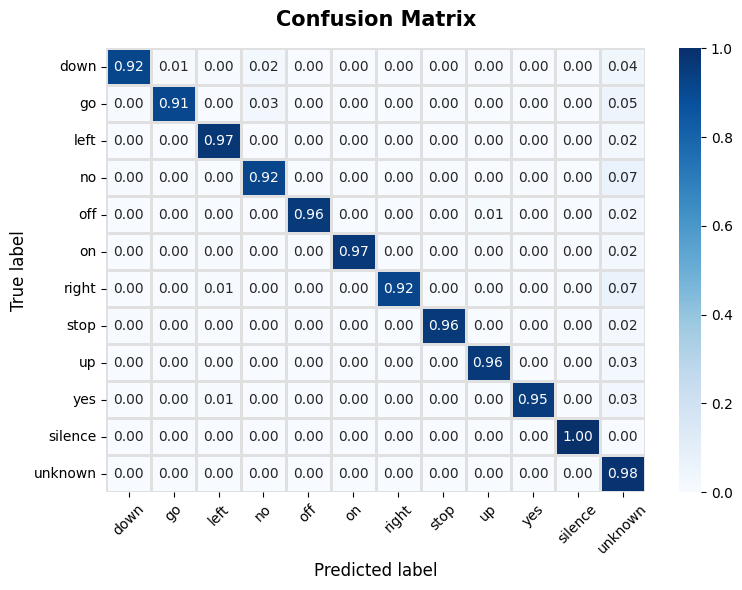


 dmodel=256, seed=0, F1=0.9562


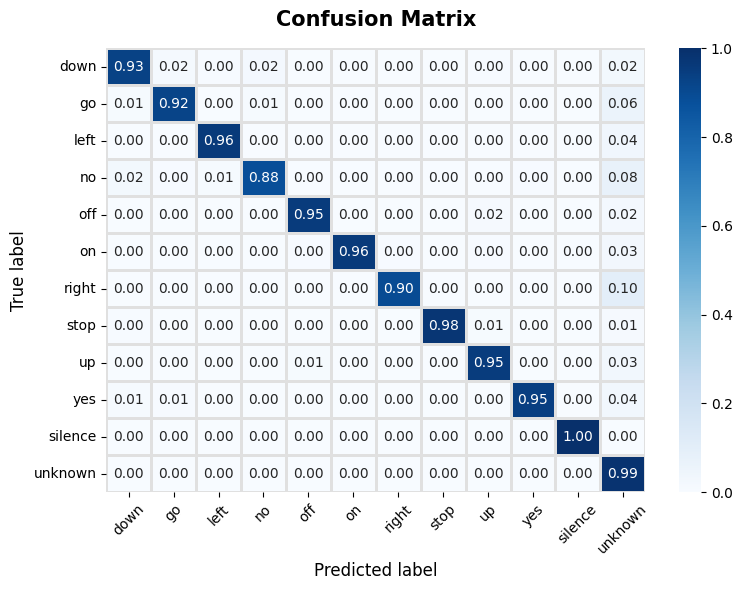


 dmodel=512, seed=2, F1=0.9441


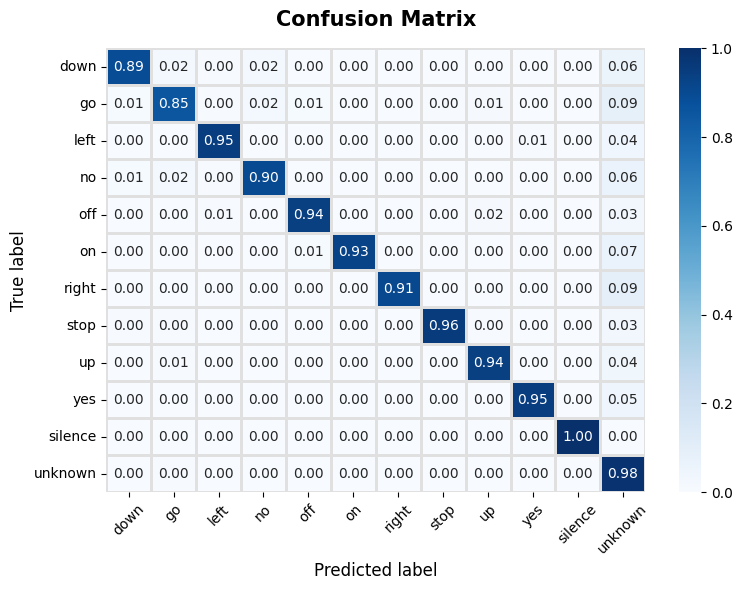

In [23]:
for dmodel in D_MODEL:
    best_seed = max(cnn_transformer_dmodel_results[dmodel], key=lambda s: cnn_transformer_dmodel_results[dmodel][s]['test_macro_f1'])
    best_result = cnn_transformer_dmodel_results[dmodel][best_seed]
    print(f'\n dmodel={dmodel}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])